# 04 — Hypothesis Testing
**FoodHub Order Analysis**

Formal statistical testing of all three hypotheses from `docs/hypothesis_testing.md`,
at **α = 0.05**. For each hypothesis we report the test statistic, p-value, effect
size, and a plain-language decision. Where a parametric test's assumptions are
questionable, a non-parametric equivalent is run as a robustness check.

Data: `../data/processed/foodhub_analytical_clean.csv`


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
ALPHA = 0.05

df = pd.read_csv("../data/processed/foodhub_analytical_clean.csv")
print("Shape:", df.shape, "| alpha =", ALPHA)

Shape: (1898, 23) | alpha = 0.05


## Hypothesis 1 — Do weekend orders take longer to fulfill?

- **H₀:** mean(weekend total time) ≤ mean(weekday total time)
- **H₁:** mean(weekend total time) > mean(weekday total time)  *(one-sided, as claimed)*
- **Test:** Welch's t-test (primary) + Mann–Whitney U (robustness). Subset: all 1,898 orders.

In [2]:
wk = df.loc[df.day_of_the_week=="Weekday", "total_fulfillment_time"]
we = df.loc[df.day_of_the_week=="Weekend", "total_fulfillment_time"]
print(f"Weekday : n={len(wk)}, mean={wk.mean():.2f}, median={wk.median():.0f}, sd={wk.std():.2f}")
print(f"Weekend : n={len(we)}, mean={we.mean():.2f}, median={we.median():.0f}, sd={we.std():.2f}")

# Primary: Welch t-test, H1 = weekend > weekday
t, p_greater = stats.ttest_ind(we, wk, equal_var=False, alternative="greater")
# Robustness: Mann-Whitney, weekend > weekday
u, pu = stats.mannwhitneyu(we, wk, alternative="greater")
# Effect size (Cohen's d, pooled)
psd = np.sqrt(((len(we)-1)*we.var() + (len(wk)-1)*wk.var()) / (len(we)+len(wk)-2))
d = (we.mean() - wk.mean()) / psd
print(f"\nWelch t = {t:.3f}   one-sided p(weekend>weekday) = {p_greater:.4f}")
print(f"Mann-Whitney U = {u:.0f}   one-sided p = {pu:.4f}")
print(f"Mean difference (weekend - weekday) = {we.mean()-wk.mean():.2f} min | Cohen's d = {d:.3f}")

# For completeness, the reverse one-sided test (weekday slower)
t2, p_less = stats.ttest_ind(we, wk, equal_var=False, alternative="less")
print(f"\n(Reverse) one-sided p(weekend<weekday) = {p_less:.2e}")

Weekday : n=547, mean=55.55, median=55, sd=5.57
Weekend : n=1351, mean=49.91, median=50, sd=6.62

Welch t = -18.906   one-sided p(weekend>weekday) = 1.0000
Mann-Whitney U = 198394   one-sided p = 1.0000
Mean difference (weekend - weekday) = -5.65 min | Cohen's d = -0.891

(Reverse) one-sided p(weekend<weekday) = 3.10e-70


/tmp/ipykernel_2956/3273288213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day_of_the_week", y="total_fulfillment_time",


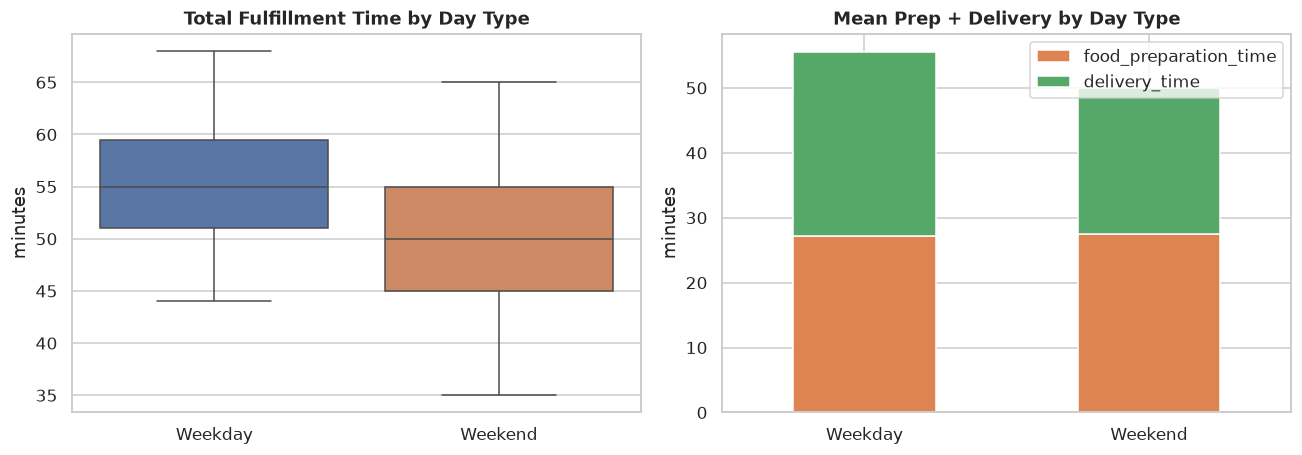

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.3))
sns.boxplot(data=df, x="day_of_the_week", y="total_fulfillment_time",
            order=["Weekday","Weekend"], palette=["#4C72B0","#DD8452"], ax=ax[0])
ax[0].set_title("Total Fulfillment Time by Day Type"); ax[0].set_xlabel(""); ax[0].set_ylabel("minutes")
comp = df.groupby("day_of_the_week")[["food_preparation_time","delivery_time"]].mean().reindex(["Weekday","Weekend"])
comp.plot(kind="bar", stacked=True, color=["#DD8452","#55A868"], ax=ax[1])
ax[1].set_title("Mean Prep + Delivery by Day Type"); ax[1].set_ylabel("minutes"); ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Decision — H1: REJECT H₁ (weekend is NOT slower).**
The one-sided p-value for "weekend > weekday" is **1.000** — no support at all. In fact
the data show the **opposite and it is highly significant**: weekends are **~5.6 min
FASTER** (weekend mean 49.9 vs weekday 55.5 min; reverse-direction p ≈ 10⁻⁶⁶), with a
**large effect size (Cohen's d ≈ −0.89)**. The stacked chart shows the gap is driven
**entirely by delivery time** (weekday 28.3 vs weekend 22.5 min); preparation time is
identical (~27 min). A plausible real-world explanation is **lighter weekend traffic**.

> **Note:** This overturns the earlier *visual* impression (notebooks 02–03) that the
> two were "nearly identical." The formal test is authoritative; the earlier read-outs
> have been corrected.

## Hypothesis 2 — Is faster fulfillment associated with higher ratings?

- **H₀:** no negative association (ρ ≥ 0) between fulfillment time and rating
- **H₁:** negative association (ρ < 0) — faster orders rate higher  *(one-sided)*
- **Test:** Spearman rank correlation (primary) + Kruskal–Wallis (robustness).
  Subset: **rated orders only (n = 1,162)**; the 736 "Not given" excluded.

In [4]:
r = df.dropna(subset=["rating_value"]).copy()
r["rating_value"] = r["rating_value"].astype(int)
print("Rated orders:", len(r))

rho, p_two = stats.spearmanr(r.total_fulfillment_time, r.rating_value)
p_one = p_two/2 if rho < 0 else 1 - p_two/2
print(f"Spearman rho = {rho:.4f}   two-sided p = {p_two:.4f}   one-sided(neg) p = {p_one:.4f}")

groups = [r.loc[r.rating_value==g, "total_fulfillment_time"] for g in [3,4,5]]
H, pk = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {H:.3f}   p = {pk:.4f}")
print("Median fulfillment time by rating:",
      {g: float(r.loc[r.rating_value==g,'total_fulfillment_time'].median()) for g in [3,4,5]})

Rated orders: 1162
Spearman rho = -0.0055   two-sided p = 0.8507   one-sided(neg) p = 0.4254
Kruskal-Wallis H = 1.754   p = 0.4161
Median fulfillment time by rating: {3: 52.0, 4: 51.0, 5: 51.0}


/tmp/ipykernel_2956/2892638548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=r, x="rating_value", y="total_fulfillment_time", palette="YlGn", ax=ax[0])
/tmp/ipykernel_2956/2892638548.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mt.index, y=mt.values, palette="YlGn", ax=ax[1])


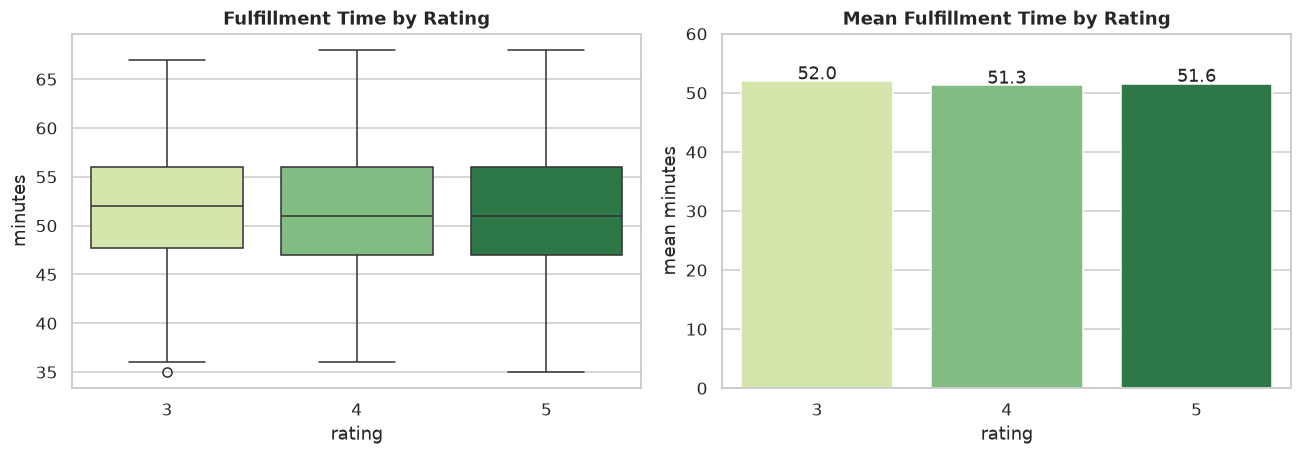

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.3))
sns.boxplot(data=r, x="rating_value", y="total_fulfillment_time", palette="YlGn", ax=ax[0])
ax[0].set_title("Fulfillment Time by Rating"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("minutes")
mt = r.groupby("rating_value")["total_fulfillment_time"].mean()
sns.barplot(x=mt.index, y=mt.values, palette="YlGn", ax=ax[1])
for i,v in enumerate(mt.values): ax[1].text(i, v+0.3, f"{v:.1f}", ha="center")
ax[1].set_title("Mean Fulfillment Time by Rating"); ax[1].set_xlabel("rating"); ax[1].set_ylabel("mean minutes"); ax[1].set_ylim(0,60)
plt.tight_layout(); plt.show()

**Decision — H2: FAIL TO REJECT H₀ (no association).**
Spearman **ρ = −0.006** (one-sided p = 0.43) — essentially **zero correlation** between
fulfillment time and rating. Kruskal–Wallis agrees (**H = 1.75, p = 0.42**): the three
rating groups have statistically indistinguishable fulfillment-time distributions
(median 52 / 51 / 51 min for ratings 3 / 4 / 5). **Delivery speed does not explain
ratings** in this data. *(Caveat: measured only on the self-selected ~61% who rated, on
a compressed 3–5 scale.)*

## Hypothesis 3 — Are demand & revenue concentrated in a few restaurants / cuisines?

- Concentration/distributional claim (not a two-group comparison).
- **Measures:** Pareto shares, Gini coefficient of order counts, and a chi-square
  goodness-of-fit test that orders are *not* uniformly distributed across cuisines.
  Subset: all 1,898 orders.

In [6]:
rc = df["restaurant_name"].value_counts()

def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x); cum = np.cumsum(x)
    return (n + 1 - 2*np.sum(cum)/cum[-1]) / n

g_rest = gini(rc.values)
top5_orders = rc.head(5).sum()/len(df)*100
top4_cuis = df["cuisine_type"].value_counts().head(4).sum()/len(df)*100
rev = df.groupby("restaurant_name")["cost_of_the_order"].sum().sort_values(ascending=False)
top5_rev = rev.head(5).sum()/df["cost_of_the_order"].sum()*100

cc = df["cuisine_type"].value_counts()
chi, pchi = stats.chisquare(cc.values)   # H0: uniform across cuisines

print(f"Restaurants: {len(rc)} | Gini(order counts) = {g_rest:.3f}")
print(f"Top 5 restaurants  = {top5_orders:.1f}% of orders, {top5_rev:.1f}% of revenue")
print(f"Top 4 cuisines     = {top4_cuis:.1f}% of orders")
print(f"Chi-square GoF (uniform cuisines): chi2 = {chi:.1f}, p = {pchi:.2e}")

Restaurants: 178 | Gini(order counts) = 0.707
Top 5 restaurants  = 33.4% of orders, 33.2% of revenue
Top 4 cuisines     = 82.6% of orders
Chi-square GoF (uniform cuisines): chi2 = 3369.3, p = 0.00e+00


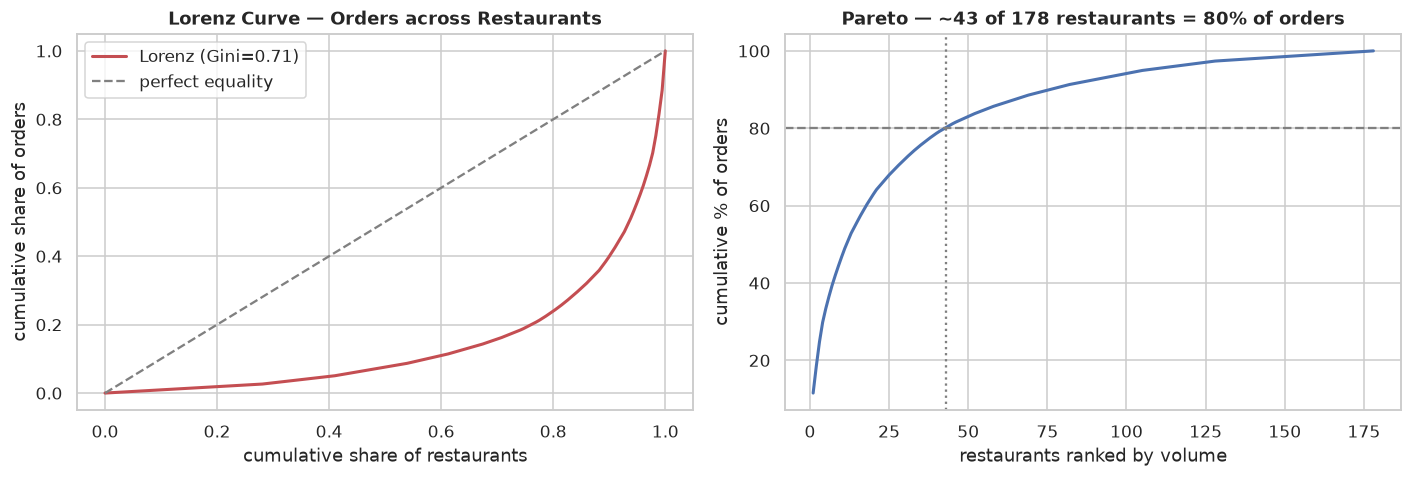

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
# Lorenz curve for restaurant order concentration
x = np.sort(rc.values); cum = np.cumsum(x)/x.sum()
xs = np.arange(1, len(x)+1)/len(x)
ax[0].plot(np.concatenate([[0],xs]), np.concatenate([[0],cum]), color="#C44E52", lw=2, label=f"Lorenz (Gini={g_rest:.2f})")
ax[0].plot([0,1],[0,1], "--", color="gray", label="perfect equality")
ax[0].set_title("Lorenz Curve — Orders across Restaurants")
ax[0].set_xlabel("cumulative share of restaurants"); ax[0].set_ylabel("cumulative share of orders"); ax[0].legend()
# Pareto of cumulative orders by ranked restaurant
cumo = rc.cumsum()/rc.sum()*100
ax[1].plot(range(1,len(cumo)+1), cumo.values, color="#4C72B0", lw=2)
ax[1].axhline(80, color="gray", ls="--");
n80 = int((cumo<=80).sum())+1
ax[1].axvline(n80, color="gray", ls=":")
ax[1].set_title(f"Pareto — ~{n80} of {len(rc)} restaurants = 80% of orders")
ax[1].set_xlabel("restaurants ranked by volume"); ax[1].set_ylabel("cumulative % of orders")
plt.tight_layout(); plt.show()

**Decision — H3: SUPPORTED.**
Concentration is strong and unambiguous. The **Gini coefficient of order counts is
0.71** (0 = perfectly even, 1 = maximally concentrated), the **top 5 of 178 restaurants
capture ~33% of both orders and revenue**, and the **top 4 cuisines cover ~83% of
orders**. The chi-square goodness-of-fit test decisively rejects a uniform cuisine
distribution (**χ² = 3,369, p ≈ 0**). Demand and revenue are heavily concentrated in a
small set of restaurants and cuisines — and (from earlier analysis) this is driven by
**volume, not premium pricing**.

## Results summary

| # | Hypothesis (as stated) | Test | Statistic | p-value | Decision |
|---|------------------------|------|-----------|---------|----------|
| **H1** | Weekend orders take **longer** | Welch t (1-sided) | t = −18.9 | 1.000 | **Rejected** — opposite is true: weekends are ~5.6 min **faster** (d≈−0.89), via delivery time |
| **H2** | Faster fulfillment → higher rating | Spearman ρ | ρ = −0.006 | 0.43 | **Fail to reject H₀** — no association |
| **H3** | Demand/revenue concentrated | Gini + χ² GoF | Gini 0.71; χ²=3369 | ≈ 0 | **Supported** — strong concentration |

**Takeaways for the business:**
1. **Weekends run faster, not slower** — the operation scales well under weekend load;
   the slower *weekday* delivery (likely traffic) is the real efficiency target.
2. **Speed is not the satisfaction lever** — ratings are flat across delivery speed, so
   improving ratings (and rating *coverage*) needs a different approach.
3. **The business rests on a concentrated core** — a handful of restaurants/cuisines
   drive most orders and revenue; protect and grow those partnerships.
